<a href="https://colab.research.google.com/github/ekanshkhare00000/PERCEPTRON/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd

In [17]:
match = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')

In [18]:
match.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [19]:
match.shape

(756, 18)

In [20]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [21]:
total_score_df = delivery.groupby(['match_id','inning']).sum()['total_runs'].reset_index()

In [22]:
total_score_df = total_score_df[total_score_df['inning'] == 1]

In [23]:
total_score_df

,match_id,inning,total_runs
0,1,1,207
2,2,1,184
4,3,1,183
6,4,1,163
8,5,1,157
...,...,...,...
1518,11347,1,143
1520,11412,1,136
1522,11413,1,171
1524,11414,1,155


In [24]:
match_df = match.merge(total_score_df[['match_id','total_runs']],left_on='id',right_on='match_id')

In [25]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,143
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,136
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,11413,171
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,155


In [26]:
match_df['team1'].unique()

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Delhi Capitals'], dtype=object)

In [27]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [28]:
match_df['team1'] = match_df['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
match_df['team2'] = match_df['team2'].str.replace('Delhi Daredevils','Delhi Capitals')

match_df['team1'] = match_df['team1'].str.replace('Deccan Chargers','Sunrisers Hyderabad')
match_df['team2'] = match_df['team2'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

In [29]:
match_df = match_df[match_df['team1'].isin(teams)]
match_df = match_df[match_df['team2'].isin(teams)]

In [30]:
match_df.shape

(641, 20)

In [31]:
match_df = match_df[match_df['dl_applied'] == 0]

In [32]:
match_df = match_df[['match_id','city','winner','total_runs']]

In [33]:
delivery_df = match_df.merge(delivery,on='match_id')

# Filter for the second inning
delivery_df = delivery_df[delivery_df['inning'] == 2]

# Convert total_runs_y to numeric, coercing errors to NaN
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')

# Calculate current_score for each match
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

# Calculate runs_left
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

# Calculate balls_left (120 balls total for 20 overs, starting from 126 and decrementing by ball)
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])

# Correctly calculate player_dismissed (1 if dismissed, 0 otherwise)
# This uses the original 'player_dismissed' column from the merge
delivery_df['player_dismissed_int'] = delivery_df['player_dismissed'].notna().astype(int)

# Calculate wickets (remaining)
# Group by match_id to get wickets fallen per match
wickets_fallen = delivery_df.groupby('match_id')['player_dismissed_int'].cumsum()
delivery_df['wickets'] = 10 - wickets_fallen

# Calculate Current Run Rate (crr)
# Avoid division by zero for overs bowled (120 - balls_left)
delivery_df['crr'] = (delivery_df['current_score'] * 6) / (120 - delivery_df['balls_left']).replace(0, 1) # Replace 0 with 1 to avoid division by zero

# Calculate Required Run Rate (rrr)
# Avoid division by zero for balls_left
delivery_df['rrr'] = (delivery_df['runs_left'] * 6) / delivery_df['balls_left'].replace(0, 1) # Replace 0 with 1 to avoid division by zero

# Define the result function
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

# Apply the result function
delivery_df['result'] = delivery_df.apply(result, axis=1)

# Select final features for the model
final_df = delivery_df[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr','result']]

# Sample the dataframe (shuffle rows)
final_df = final_df.sample(final_df.shape[0])

# Filter out rows where balls_left is negative or zero to avoid division by zero in rrr during prediction and ensure valid ball counts
final_df = final_df[final_df['balls_left'] >= 0]
final_df = final_df[final_df['balls_left'] != 0]

# Drop any remaining NaN values (e.g., from rrr/crr calculations where balls_left or overs_bowled was 0 before handling)
final_df.dropna(inplace=True)


In [34]:
delivery_df = delivery_df[delivery_df['inning'] == 2]

In [35]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,NaN,NaN,1,206,119,0,10,6.000000,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,NaN,NaN,1,206,118,0,10,3.000000,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,NaN,NaN,1,206,117,0,10,2.000000,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,NaN,NaN,3,204,116,0,10,4.500000,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,NaN,NaN,7,200,115,0,10,8.400000,10.434783,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,NaN,NaN,152,0,4,0,5,7.862069,0.000000,0
149574,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,NaN,NaN,154,-2,3,0,5,7.897436,-4.000000,0
149575,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,run out,KH Pandya,155,-3,2,1,4,7.881356,-9.000000,0
149576,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,NaN,NaN,157,-5,1,0,4,7.915966,-30.000000,0


In [36]:
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')
print(delivery_df['total_runs_y'].dtype)
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

int64


In [37]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

In [38]:
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])

In [39]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,NaN,NaN,1,206,119,0,10,6.000000,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,NaN,NaN,1,206,118,0,10,3.000000,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,NaN,NaN,1,206,117,0,10,2.000000,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,NaN,NaN,3,204,116,0,10,4.500000,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,NaN,NaN,7,200,115,0,10,8.400000,10.434783,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,NaN,NaN,152,0,4,0,5,7.862069,0.000000,0
149574,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,NaN,NaN,154,-2,3,0,5,7.897436,-4.000000,0
149575,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,run out,KH Pandya,155,-3,2,1,4,7.881356,-9.000000,0
149576,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,NaN,NaN,157,-5,1,0,4,7.915966,-30.000000,0


In [40]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].notna().astype(int)

wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
delivery_df['wickets'] = 10 - wickets

In [41]:
delivery_df['total_runs_y'] = pd.to_numeric(delivery_df['total_runs_y'], errors='coerce')
print(delivery_df['total_runs_y'].dtype)
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()

int64


In [42]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']

In [43]:
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])

In [44]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,NaN,NaN,1,206,119,0,10,6.000000,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,NaN,NaN,1,206,118,0,10,3.000000,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,NaN,NaN,1,206,117,0,10,2.000000,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,NaN,NaN,3,204,116,0,10,4.500000,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,NaN,NaN,7,200,115,0,10,8.400000,10.434783,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149573,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,NaN,NaN,152,0,4,0,5,7.862069,0.000000,0
149574,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,NaN,NaN,154,-2,3,0,5,7.897436,-4.000000,0
149575,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,run out,KH Pandya,155,-3,2,1,4,7.881356,-9.000000,0
149576,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,NaN,NaN,157,-5,1,0,4,7.915966,-30.000000,0


In [45]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].notna().astype(int)
wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
delivery_df['wickets'] = 10 - wickets

In [46]:
delivery_df.head()

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,NaN,NaN,1,206,119,0,9,6.0,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,NaN,NaN,1,206,118,0,8,3.0,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,NaN,NaN,1,206,117,0,7,2.0,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,NaN,NaN,3,204,116,0,6,4.5,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,NaN,NaN,7,200,115,0,5,8.4,10.434783,0


In [47]:
# crr = runs/overs
delivery_df['crr'] = (delivery_df['current_score']*6)/(120 - delivery_df['balls_left'])

In [48]:
delivery_df['rrr'] = (delivery_df['runs_left']*6)/delivery_df['balls_left']

In [49]:
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

In [50]:
delivery_df['result'] = delivery_df.apply(result,axis=1)

In [51]:
final_df = delivery_df[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr','result']]

In [52]:
final_df = final_df.sample(final_df.shape[0])

In [53]:
final_df.sample()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
137419,Kings XI Punjab,Mumbai Indians,Mohali,28,23,-92,187,9.835052,7.304348,1


In [54]:
final_df.dropna(inplace=True)

In [55]:
final_df = final_df[final_df['balls_left'] != 0]

In [56]:
X = final_df.iloc[:,:-1]
y = final_df.iloc[:,-1]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [57]:
X_train

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr
72229,Kolkata Knight Riders,Chennai Super Kings,Chennai,63,44,-71,190,10.026316,8.590909
139093,Sunrisers Hyderabad,Delhi Capitals,Delhi,63,83,-28,134,11.513514,4.554217
57047,Royal Challengers Bangalore,Chennai Super Kings,Bangalore,120,109,-1,128,4.363636,6.605505
44517,Royal Challengers Bangalore,Deccan Chargers,Nagpur,13,1,-115,151,6.957983,78.000000
146835,Kings XI Punjab,Sunrisers Hyderabad,Hyderabad,166,73,-41,232,8.425532,13.643836
...,...,...,...,...,...,...,...,...,...
23967,Mumbai Indians,Kings XI Punjab,Durban,112,105,-7,119,2.800000,6.400000
46280,Chennai Super Kings,Kings XI Punjab,Dharamsala,192,118,8,192,0.000000,9.762712
93152,Kolkata Knight Riders,Delhi Daredevils,Delhi,158,115,5,160,2.400000,8.243478
55966,Mumbai Indians,Deccan Chargers,Mumbai,49,17,-99,135,5.009709,17.294118


In [58]:
def match_summary(row):
    print("Batting Team-" + row['batting_team'] + " | Bowling Team-" + row['bowling_team'] + " | Target- " + str(row['total_runs_x']))

In [59]:
def match_progression(x_df,match_id,pipe):
    match = x_df[x_df['match_id'] == match_id]
    match = match[(match['ball'] == 6)]
    temp_df = match[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr']].dropna()
    temp_df = temp_df[temp_df['balls_left'] != 0]
    result = pipe.predict_proba(temp_df)
    temp_df['lose'] = np.round(result.T[0]*100,1)
    temp_df['win'] = np.round(result.T[1]*100,1)
    temp_df['end_of_over'] = range(1,temp_df.shape[0]+1)

    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0,target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)
    wickets = list(temp_df['wickets'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0,10)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[0:temp_df.shape[0]]

    print("Target-",target)
    temp_df = temp_df[['end_of_over','runs_after_over','wickets_in_over','lose','win']]
    return temp_df,target

In [60]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Kings XI Punjab',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [61]:
delivery_df['city'].unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi', 'Abu Dhabi',
       'Sharjah', nan, 'Mohali', 'Bengaluru'], dtype=object)

In [62]:
print('Unique values in player_dismissed before conversion:')
display(delivery_df['player_dismissed'].unique())

print('Are there any empty strings in player_dismissed?')
display(delivery_df['player_dismissed'].apply(lambda x: isinstance(x, str) and x == '').any())

Unique values in player_dismissed before conversion:


array([1])

Are there any empty strings in player_dismissed?


np.False_

In [63]:
delivery_df.head()

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,dismissal_kind,fielder,current_score,runs_left,balls_left,player_dismissed_int,wickets,crr,rrr,result
125,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,...,NaN,NaN,1,206,119,0,9,6.0,10.386555,0
126,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,...,NaN,NaN,1,206,118,0,8,3.0,10.474576,0
127,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,...,NaN,NaN,1,206,117,0,7,2.0,10.564103,0
128,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,...,NaN,NaN,3,204,116,0,6,4.5,10.551724,0
129,1,Hyderabad,Sunrisers Hyderabad,207,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,...,NaN,NaN,7,200,115,0,5,8.4,10.434783,0


In [64]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define categorical and numerical features
categorical_features = ['batting_team', 'bowling_team', 'city']
numerical_features = ['runs_left', 'balls_left', 'wickets', 'total_runs_x', 'crr', 'rrr']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Fit and transform X_train and X_test using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Define the ANN model
# Adjust input_shape based on the output of the preprocessor
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model (before training)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with preprocessed data
model.fit(X_train_processed, y_train, epochs=10, batch_size=32, verbose=1)

# Evaluate the model with preprocessed data
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1784/1784 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8536 - loss: 0.3276
Epoch 2/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9337 - loss: 0.1560
Epoch 3/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9515 - loss: 0.1115
Epoch 4/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9594 - loss: 0.0944
Epoch 5/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9648 - loss: 0.0816
Epoch 6/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9705 - loss: 0.0713
Epoch 7/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9728 - loss: 0.0649
Epoch 8/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9758 - loss: 0.0582
Epoch 9/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9772 - loss: 0.0547
Epoch 10/10
1784/1784 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9787 - loss: 0.0513
Test Loss: 0.0292
Test Accuracy: 0.9872


In [65]:
# Test the model with a sample input
# Let's take the first row from X_test as an example
sample_input_df = X_test.iloc[[6]]

# Preprocess the sample input
sample_input_processed = preprocessor.transform(sample_input_df)

# Make a prediction
prediction = model.predict(sample_input_processed)

print(f"Sample Input:\n{sample_input_df}")
print(f"\nPredicted Winning Probability for Batting Team: {prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Sample Input:
          batting_team      bowling_team       city  runs_left  balls_left  \
70523  Deccan Chargers  Rajasthan Royals  Hyderabad         43          50   

       wickets  total_runs_x       crr   rrr  
70523      -65           126  7.114286  5.16  

Predicted Winning Probability for Batting Team: 1.0000


In [66]:
import pickle

# Save the preprocessor
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print("Preprocessor saved as preprocessor.pkl")

# Save the Keras model
model.save('ann_model.h5')
print("Keras model saved as ann_model.h5")

Preprocessor saved as preprocessor.pkl
Keras model saved as ann_model.h5


Overall Test Accuracy: 0.9872
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


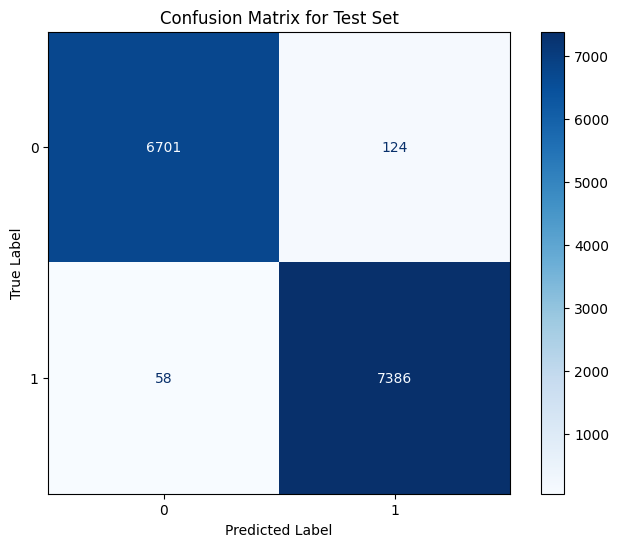

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate the model on the test set (if not already done)
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Overall Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
y_pred_proba = model.predict(X_test_processed).flatten()
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions (0 or 1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [68]:
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

# Load the preprocessor and the model
with open('preprocessor.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

loaded_model = tf.keras.models.load_model('ann_model.h5')

def predict_match_outcome(
    batting_team, bowling_team, city, runs_left, balls_left, wickets, total_runs_x, crr, rrr
):
    # Create a DataFrame from the input parameters
    input_data = pd.DataFrame([[batting_team, bowling_team, city, runs_left, balls_left, wickets, total_runs_x, crr, rrr]],
                               columns=['batting_team', 'bowling_team', 'city', 'runs_left', 'balls_left', 'wickets', 'total_runs_x', 'crr', 'rrr'])

    # Preprocess the input data using the loaded preprocessor
    input_processed = loaded_preprocessor.transform(input_data)

    # Make a prediction using the loaded model
    prediction = loaded_model.predict(input_processed)

    # Return the winning probability for the batting team
    return prediction[0][0]

def get_int_input(prompt):
    while True:
        try:
            return int(input(prompt))
        except ValueError:
            print("Invalid input. Please enter a whole number.")

def get_float_input(prompt):
    while True:
        try:
            return float(input(prompt))
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

# Define valid team names and their short forms
teams_map = {
    "CSK": "Chennai Super Kings",
    "MI": "Mumbai Indians",
    "RCB": "Royal Challengers Bangalore",
    "KKR": "Kolkata Knight Riders",
    "DC": "Delhi Capitals",
    "SRH": "Sunrisers Hyderabad",
    "PBKS": "Kings XI Punjab", # Corrected from 'Punjab Kings' to match data
    "RR": "Rajasthan Royals",
    "Chennai Super Kings": "Chennai Super Kings",
    "Mumbai Indians": "Mumbai Indians",
    "Royal Challengers Bangalore": "Royal Challengers Bangalore",
    "Kolkata Knight Riders": "Kolkata Knight Riders",
    "Delhi Capitals": "Delhi Capitals",
    "Sunrisers Hyderabad": "Sunrisers Hyderabad",
    "Kings XI Punjab": "Kings XI Punjab",
    "Rajasthan Royals": "Rajasthan Royals"
}

def get_team_input(prompt, team_type):
    while True:
        team_name_input = input(prompt).strip()
        full_team_name = teams_map.get(team_name_input.upper()) # Check for short form (case-insensitive)
        if not full_team_name:
            full_team_name = teams_map.get(team_name_input) # Check for full name (case-sensitive as provided by user)

        if full_team_name:
            return full_team_name
        else:
            print(f"Invalid {team_type} team name. Please enter a valid team name or its short form (e.g., CSK, MI, RCB, KKR, DC, SRH, PBKS, RR).")

# --- Interactive User Input for Prediction ---
print("\nEnter match details for prediction:\n")

user_batting_team = get_team_input("Enter Batting Team (e.g., MI or Mumbai Indians): ", "batting")
user_bowling_team = get_team_input("Enter Bowling Team (e.g., CSK or Chennai Super Kings): ", "bowling")

# Default city is used as the model was trained with it.
# To remove it completely, the model would need to be retrained.
user_city = 'Mumbai' # Default value if user doesn't input it

user_total_runs_x = get_int_input("Enter First Innings Total Score (Target): ")
user_current_score = get_int_input("Enter Current Score of Batting Team: ")
user_balls_played = get_int_input("Enter Balls Played by Batting Team: ")
user_wickets_fallen = get_int_input("Enter Wickets Fallen for Batting Team: ")

# Calculate derived features
runs_left = user_total_runs_x - user_current_score
balls_left = 120 - user_balls_played
wickets = 10 - user_wickets_fallen # Model expects wickets remaining

# Handle division by zero for CRR and RRR
crr_divisor = user_balls_played if user_balls_played > 0 else 1
crr = (user_current_score * 6) / crr_divisor

rrr_divisor = balls_left if balls_left > 0 else 1
rrr = (runs_left * 6) / rrr_divisor

predicted_prob_batting = predict_match_outcome(
    user_batting_team, user_bowling_team, user_city,
    runs_left, balls_left, wickets, user_total_runs_x,
    crr, rrr
)

predicted_prob_bowling = 1 - predicted_prob_batting

print(f"\nPredicted Winning Probability for {user_batting_team}: {predicted_prob_batting:.4f} ({predicted_prob_batting*100:.2f}%)")
print(f"Predicted Winning Probability for {user_bowling_team}: {predicted_prob_bowling:.4f} ({predicted_prob_bowling*100:.2f}%)")

# Interpretation of the probability
if predicted_prob_batting > 0.5:
    print(f"\n{user_batting_team} has a higher chance of winning.")
else:
    print(f"\n{user_bowling_team} has a higher chance of winning.")


Enter match details for prediction:

Enter Batting Team (e.g., MI or Mumbai Indians): srh
Enter Bowling Team (e.g., CSK or Chennai Super Kings): KKR
Enter First Innings Total Score (Target): 150
Enter Current Score of Batting Team: 57
Enter Balls Played by Batting Team: 56
Enter Wickets Fallen for Batting Team: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Predicted Winning Probability for Sunrisers Hyderabad: 0.1317 (13.17%)
Predicted Winning Probability for Kolkata Knight Riders: 0.8683 (86.83%)

Kolkata Knight Riders has a higher chance of winning.
